# AeroTwin — AI4I Predictive Maintenance EDA & Preprocessing
This notebook validates the tabular predictive-maintenance fault classification pipeline.

In [3]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Configuration
SEED = 42
np.random.seed(SEED)

AI4I_DIR = r"C:\Users\mohit\Documents\AeroTwin_datasets\ai4i+2020+predictive+maintenance+dataset"
CACHE_DIR = "data/cache"
os.makedirs(CACHE_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook")

## 01. Load and Inspect
We load the dataset and check its structure.

In [4]:
df = pd.read_csv(os.path.join(AI4I_DIR, "ai4i2020.csv"))
print(f"Dataset shape: {df.shape}")
display(df.head())

print("Missing values:")
print(df.isna().sum())

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


## 03. Remove Identifiers and 04. Prevent Target Leakage
The columns `UDI` and `Product ID` are identifiers.
The columns `TWF`, `HDF`, `PWF`, `OSF`, `RNF` describe the specific failure mechanism. Since we are trying to predict the binary `Machine failure` column, keeping these specific failure markers would cause target leakage (they perfectly predict the target).

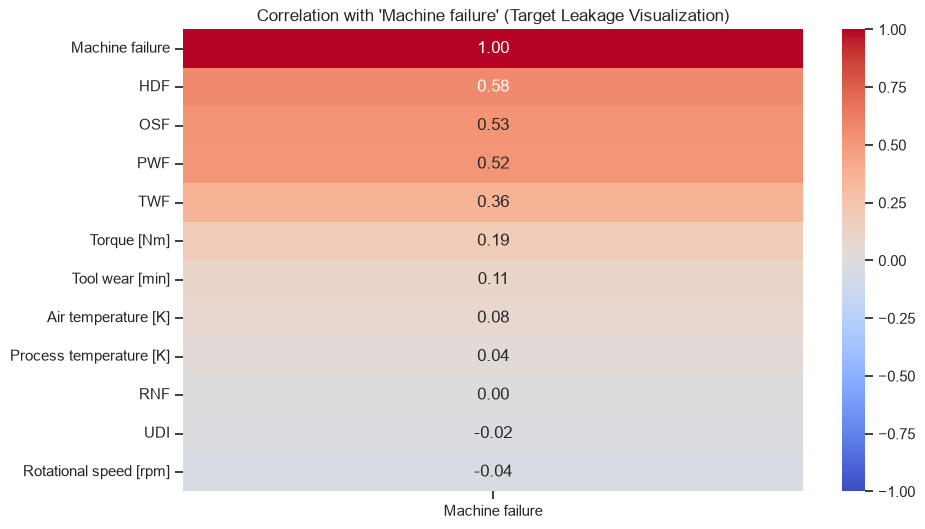

Notice how HDF, OSF, PWF, TWF, and RNF have VERY HIGH correlations with the target.
The physical sensors (like Torque or Temp) have realistic, much lower correlations.
If we leave the specific failure columns in, the model will just memorize them instead of learning from the sensors!


In [5]:
# Let's visualize TARGET LEAKAGE using a Correlation Heatmap!
# We will see how strongly each column correlates with the final 'Machine failure' answer.

plt.figure(figsize=(10, 6))
# Select only numerical columns for correlation
num_df = df.select_dtypes(include=[np.number])

# Calculate correlation of all features with the target 'Machine failure'
correlations = num_df.corr()[['Machine failure']].sort_values(by='Machine failure', ascending=False)

sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title("Correlation with 'Machine failure' (Target Leakage Visualization)")
plt.show()

print("Notice how HDF, OSF, PWF, TWF, and RNF have VERY HIGH correlations with the target.")
print("The physical sensors (like Torque or Temp) have realistic, much lower correlations.")
print("If we leave the specific failure columns in, the model will just memorize them instead of learning from the sensors!")


In [6]:
# Show why we drop leakage columns: they perfectly predict the target!
leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Checking Target Leakage...")
df['Any_Specific_Failure'] = (df[leakage_cols].sum(axis=1) > 0).astype(int)
leakage_crosstab = pd.crosstab(df['Any_Specific_Failure'], df['Machine failure'])
display(leakage_crosstab)
print("Notice how the specific failures almost perfectly align with the target 'Machine failure'. Keeping them is cheating!\n")

identifiers = ['UDI', 'Product ID']
df_clean = df.drop(columns=identifiers + leakage_cols + ['Any_Specific_Failure'])
print(f"Dropped {len(identifiers)} identifiers and {len(leakage_cols)} leakage columns.")
print(f"Cleaned shape: {df_clean.shape}")

# Rename columns to remove spaces and special characters for easier processing
df_clean.columns = [col.replace(' ', '_').replace('[', '').replace(']', '') for col in df_clean.columns]
display(df_clean.head())

Checking Target Leakage...


Machine failure,0,1
Any_Specific_Failure,,
0,9643,9
1,18,330


Notice how the specific failures almost perfectly align with the target 'Machine failure'. Keeping them is cheating!

Dropped 2 identifiers and 5 leakage columns.
Cleaned shape: (10000, 7)


,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


## 05. EDA (Exploratory Data Analysis)
Let's check the class distribution (it's heavily imbalanced) and some feature relationships.

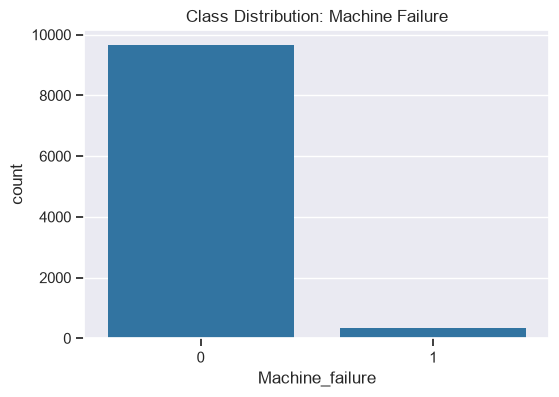

Failure Rate: 3.39%


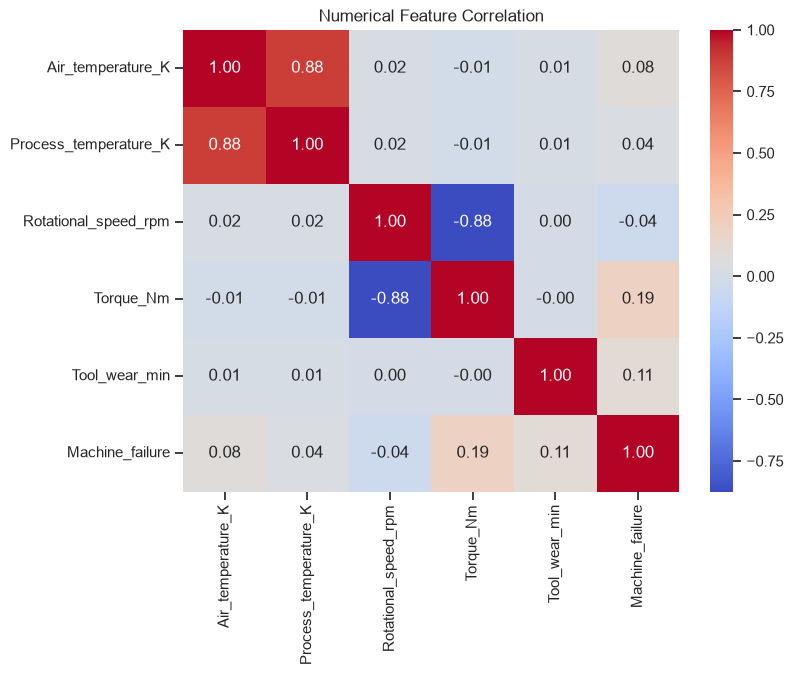

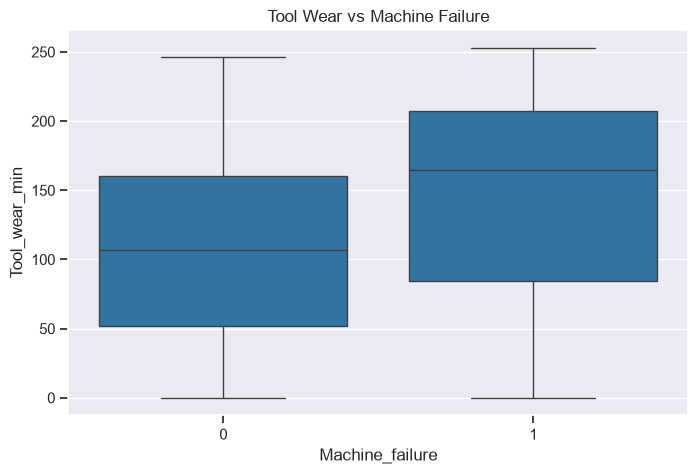

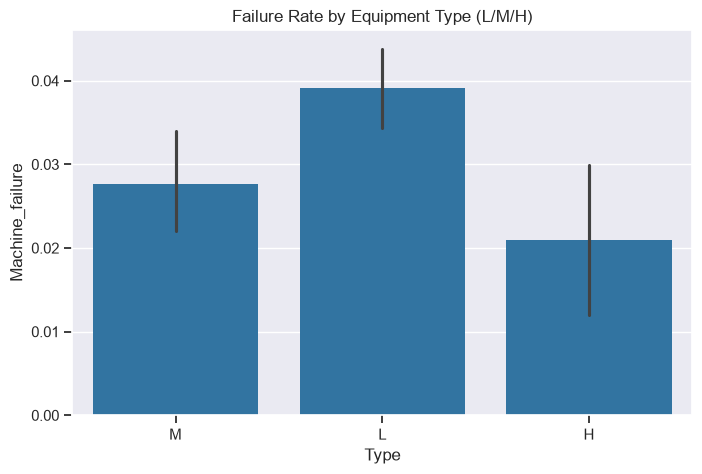

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Machine_failure')
plt.title("Class Distribution: Machine Failure")
plt.show()

failure_rate = df_clean['Machine_failure'].mean() * 100
print(f"Failure Rate: {failure_rate:.2f}%")

# Correlation matrix for numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Numerical Feature Correlation")
plt.show()

# Visualize Tool wear vs Failure
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Machine_failure', y='Tool_wear_min')
plt.title("Tool Wear vs Machine Failure")
plt.show()

# Visualize Failure Rate by Type
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, x='Type', y='Machine_failure')
plt.title("Failure Rate by Equipment Type (L/M/H)")
plt.show()

## 06. Encode Categorical Data
We one-hot encode the `Type` feature.

In [8]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
type_encoded = encoder.fit_transform(df_clean[['Type']])
type_cols = encoder.get_feature_names_out(['Type'])

df_encoded = pd.concat([
    df_clean.drop(columns=['Type']),
    pd.DataFrame(type_encoded, columns=type_cols)
], axis=1)

display(df_encoded.head())

,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0.0,0.0,1.0
1,298.2,308.7,1408,46.3,3,0,0.0,1.0,0.0
2,298.1,308.5,1498,49.4,5,0,0.0,1.0,0.0
3,298.2,308.6,1433,39.5,7,0,0.0,1.0,0.0
4,298.2,308.7,1408,40.0,9,0,0.0,1.0,0.0


## 07. Stratified Split
70% Train, 15% Validation, 15% Test. We stratify by `Machine_failure` to maintain the failure rate across splits.

In [9]:
X = df_encoded.drop(columns=['Machine_failure'])
y = df_encoded['Machine_failure'].values

# Train (70%), Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)

# Val (15%), Test (15%) -> split Temp in half
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train size: {X_train.shape[0]} (Failures: {sum(y_train)})")
print(f"Val size:   {X_val.shape[0]} (Failures: {sum(y_val)})")
print(f"Test size:  {X_test.shape[0]} (Failures: {sum(y_test)})")

Train size: 7000 (Failures: 237)
Val size:   1500 (Failures: 51)
Test size:  1500 (Failures: 51)


## 08. Scaling
We fit a `StandardScaler` on the numerical columns of the training set ONLY to prevent data leakage, then apply it to the validation and test sets.

In [10]:
num_cols = ['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## 09. Save Cache

In [11]:
cache_data = {
    'X_train': X_train_scaled.values,
    'X_val': X_val_scaled.values,
    'X_test': X_test_scaled.values,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    'feature_names': X_train_scaled.columns.tolist(),
    'encoder': encoder,
    'scaler': scaler
}

with open(os.path.join(CACHE_DIR, "ai4i_processed.pkl"), "wb") as f:
    pickle.dump(cache_data, f)
    
print("AI4I pipeline complete and cache exported!")

AI4I pipeline complete and cache exported!
